# EECS 498-007/598-005 Assignment 1-1: PyTorch 101

Before we start, please put your name and UMID in following format

: Firstname LASTNAME, #00000000   //   e.g.) Justin JOHNSON, #12345678

**Your Answer:**   
Your NAME, #XXXXXXXX

# Setup Code
在开始之前，我们需要运行一些样板代码来设置我们的环境。每次启动笔记本时，你都需要重新运行这段设置代码。

首先，运行这个单元格以加载[自动重载](https://ipython.readthedocs.io/en/stable/config/extensions/autoreload.html?highlight=autoreload)扩展。这使我们能够编辑`.py`源文件，并将它们重新导入到笔记本中，从而获得无缝的编辑和调试体验。

In [133]:
import sys
import importlib
import types

# 1. 创建一个假的 'imp' 模块
fake_imp = types.ModuleType('imp')

# 2. 将 importlib 里最新的 reload 方法赋值给这个假模块
fake_imp.reload = importlib.reload

# 3. 将假模块注册到系统的已加载模块列表中
sys.modules['imp'] = fake_imp

# 4. 现在再运行你原来的魔法命令，IPython 就不会报错了
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [134]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Google Colab Setup
接下来，我们需要运行几个命令在Google Colab上设置我们的环境。如果你在本地机器上运行这个笔记本，可以跳过这一部分。

运行下面的单元格来挂载你的谷歌云端硬盘。点击链接，登录你的谷歌账户（就是你用来存储这个笔记本的同一个账户！），然后将授权代码复制到下方出现的文本框中。

In [135]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


现在回想一下你在谷歌云端硬盘中上传这个笔记本的路径，将其填写在下方。如果一切正常，运行下面的单元格应该会打印出作业中的文件名：
```
['pytorch101.py', 'knn.py', 'knn.ipynb', 'eecs598', 'pytorch101.ipynb']
```

In [136]:
import os

# 使用 Colab 现在的标准绝对路径格式
GOOGLE_DRIVE_PATH = '/content/drive/MyDrive/A1'

print("正在查找路径:", GOOGLE_DRIVE_PATH)
print(os.listdir(GOOGLE_DRIVE_PATH))

正在查找路径: /content/drive/MyDrive/A1
['knn.py', '.DS_Store', 'knn.ipynb', 'pytorch101.py', 'pytorch101.ipynb', '__pycache__', 'eecs598']


一旦你成功挂载了你的谷歌云端硬盘并找到了本作业的路径，请运行以下单元格，以便我们能从本作业的.py文件中导入内容。如果运行成功，它应该会打印出以下信息：

```
Hello from pytorch101.py!
```

以及文件`pytorch101.py`的最后编辑时间。

In [137]:
import sys
sys.path.append(GOOGLE_DRIVE_PATH)

import time, os
os.environ["TZ"] = "US/Eastern"
time.tzset()

from pytorch101 import hello
hello()

pytorch101_path = os.path.join(GOOGLE_DRIVE_PATH, 'pytorch101.py')
pytorch101_edit_time = time.ctime(os.path.getmtime(pytorch101_path))
print('pytorch101.py last edited on %s' % pytorch101_edit_time)

Hello from pytorch101.py!
pytorch101.py last edited on Wed Apr  1 04:20:28 2026


# Introduction

整个学期将使用Python 3和[PyTorch](https://pytorch.org/)，因此熟悉它们很重要。本笔记本中的内容借鉴了[斯坦福大学CS231n](http://cs231n.github.io/python-numpy-tutorial/)和[CS228](https://github.com/kuleshov/cs228-material/blob和 numpy 教程，但本材料主要关注 PyTorch。

本笔记本将带你了解PyTorch的许多重要特性，这些特性是你在整个学期中都需要用到的。在一些单元格和文件中，你会看到如下所示的代码块：
```python
##############################################################################
#                    TODO: Write the equation for a line                     #
##############################################################################
pass
##############################################################################
#                              END OF YOUR CODE                              #
##############################################################################
```

你应该用自己的代码替换`pass`语句，并保持代码块的完整性，如下所示：

```python
##############################################################################
#                    TODO: Write the equation for a line                     #
##############################################################################
y = m * x + b
##############################################################################
#                              END OF YOUR CODE                              #
##############################################################################
```

完成笔记本时，请遵守以下规则：
- 不要在代码块之外编写或修改任何代码
- 不要从笔记本中添加或删除任何单元格。你可以添加新的单元格来进行草稿工作，但在提交前请删除它们。
- 提交前运行所有单元格。**只有已运行的代码才能获得学分！**

最后一点极为重要，值得重申：

### 我们不会重新运行你的笔记本——只有已运行的单元格才能让你获得学分

本笔记本包含许多针对你所写代码的嵌入式完整性检查。然而，**通过这些完整性检查并不意味着你的代码是正确的！** 在评分过程中，我们可能会在额外的输入上运行你的代码，并且可能会查看你的代码，以确保你遵循了每个实现的特定指导方针。建议你为所要求编写的函数编写额外的测试用例，而不是仅仅依赖笔记本中的完整性检查。

# Python 3


如果你不熟悉 Python 3，这里有一些从 Python 2 到 Python 3 的常见变化，你应该注意。


### Print is a function

In [138]:
print("Hello!")

Hello!


没有括号，打印将无法工作。

### Floating point division by default

In [139]:
5 / 2

2.5

要进行整数除法，我们需要使用两个反斜杠：

In [140]:
5 // 2

2

### No xrange

从 Python 2 到 Python 3，xrange 已合并为“range”，Python 3 中不再有 xrange。在 Python 3 中，range(3) 生成的不是 Python 2 中的 3 个元素的列表，而是更节省内存的迭代器。

因此，

在 Python 3 中， xrange 不存在

在 Python 3 中的范围：与 Python 2 的 xrange 有非常相似的行为

In [141]:
for i in range(3):
    print(i)

0
1
2


In [142]:
range(3)

range(0, 3)

In [143]:
# 如有必要，可以使用以下内容来获得与Python 2的range类似的行为：
print(list(range(3)))

[0, 1, 2]


# PyTorch

[PyTorch](https://pytorch.org/) 是一个开源机器学习框架。PyTorch 的核心提供了一些关键功能：

- 一个多维的张量对象，类似于[numpy](https://numpy.org/) 但是拥有GPU加速.
一个经过优化的**自动求导**引擎，用于自动计算导数
- 一个简洁、模块化的API，用于构建和部署**深度学习模型**

本学期的所有编程作业我们都将使用PyTorch。本笔记本将重点介绍**张量API**，因为它是PyTorch的主要部分，我们在最初的几项作业中会用到它。

你可以通过查阅[官方教程](https://pytorch.org/tutorials/)或[阅读文档](https://pytorch.org/docs

要使用PyTorch，我们首先需要导入`torch`包。

我们还要检查版本；本课程的作业将使用PyTorch 1.10.0版本，因为这是Google Colab中的默认版本。

In [144]:
import torch
print(torch.__version__)

2.10.0+cu128


## Tensor Basics

### Creating and Accessing tensors

`torch`张量是一个多维的值网格，所有值的类型都相同，并通过非负整数元组进行索引。维度的数量称为张量的**秩**；张量的**形状**是一个整数元组，用于表示数组在每个维度上的大小。

我们可以从嵌套的Python列表初始化`torch`张量。我们可以使用方括号访问或修改PyTorch张量的元素。

从PyTorch张量中访问一个元素会返回一个PyTorch标量；我们可以使用`.item()`方法将其转换为Python标量：

In [145]:
# 从Python列表创建一个1阶张量
a = torch.tensor([1, 2, 3])
print('Here is a:')
print(a)
print('type(a): ', type(a))
print('rank of a: ', a.dim()) #维度的张量
print('a.shape: ', a.shape) #每个张量的形状

# 使用方括号访问元素
print()
print('a[0]: ', a[0])
print('type(a[0]): ', type(a[0]))
print('type(a[0].item()): ', type(a[0].item()))

# 使用方括号修改元素
a[1] = 10
print()
print('a after mutating:')
print(a)

Here is a:
tensor([1, 2, 3])
type(a):  <class 'torch.Tensor'>
rank of a:  1
a.shape:  torch.Size([3])

a[0]:  tensor(1)
type(a[0]):  <class 'torch.Tensor'>
type(a[0].item()):  <class 'int'>

a after mutating:
tensor([ 1, 10,  3])


上面的示例展示了一个一维张量；我们同样可以创建具有两个或更多维度的张量：

In [146]:
# 创建一个二维张量
b = torch.tensor([[1, 2, 3], [4, 5, 5]])
print('Here is b:')
print(b)
print('rank of b:', b.dim())
print('b.shape: ', b.shape)

# 从多维张量中访问元素
print()
print('b[0, 1]:', b[0, 1])
print('b[1, 2]:', b[1, 2])

# 对多维张量的元素进行更改
b[1, 1] = 100
print()
print('b after mutating:')
print(b)

Here is b:
tensor([[1, 2, 3],
        [4, 5, 5]])
rank of b: 2
b.shape:  torch.Size([2, 3])

b[0, 1]: tensor(2)
b[1, 2]: tensor(5)

b after mutating:
tensor([[  1,   2,   3],
        [  4, 100,   5]])


现在轮到**你**了。在文件`pytorch101.py`中，完成函数`create_sample_tensor`、`mutate_tensor`和`count_tensor_elements`的实现，以练习张量的构建、修改和形状思考。

In [147]:
from pytorch101 import create_sample_tensor, mutate_tensor, count_tensor_elements

# 创建一个示例张量
x = create_sample_tensor()
print('Here is the sample tensor:')
print(x)

# 通过设置一些元素来改变张量
indices = [(0, 0), (1, 0), (1, 1)]
values = [4, 5, 6]
mutate_tensor(x, indices, values)
print('\nAfter mutating:')
print(x)
print('\nCorrect shape: ', x.shape == (3, 2))
print('x[0, 0] correct: ', x[0, 0].item() == 4)  #item方法转化为python标量int
print('x[1, 0] correct: ', x[1, 0].item() == 5)
print('x[1, 1] correct: ', x[1, 1].item() == 6)

# 检查样本张量中的元素数量
num = count_tensor_elements(x)
print('\nNumber of elements in x: ', num)
print('Correctly counted: ', num == 6)

Here is the sample tensor:
tensor([[  0.,  10.],
        [100.,   0.],
        [  0.,   0.]])

After mutating:
tensor([[ 4., 10.],
        [ 5.,  6.],
        [ 0.,  0.]])

Correct shape:  True
x[0, 0] correct:  True
x[1, 0] correct:  True
x[1, 1] correct:  True

Number of elements in x:  6
Correctly counted:  True


### Tensor constructors

PyTorch提供了许多用于构建张量的便捷方法；这避免了使用Python列表的需求，因为在处理大量数据时，Python列表可能效率不高。一些最常用的张量构造函数如下：

- [`torch.zeros`](https://pytorch.org/docs/stable/generated/torch.zeros.html): 创建一个全为零的张量
- [`torch.ones`](https://pytorch.org/docs/stable/generated/torch.ones.html): 创建一个全为1的张量
- [`torch.rand`](https://pytorch.org/docs/stable/generated/torch.rand.html): 创建一个包含均匀随机数的张量

你可以在[文档](https://pytorch.org/docs/stable/torch.html#creation-ops)中找到张量创建操作的完整列表.

In [148]:
# 创建一个全为0的张量
a = torch.zeros(2, 3)
print('tensor of zeros:')
print(a)

# 全为1的张量
b = torch.ones(1, 2)
print('\ntensor of ones:')
print(b)

# 创建一个3x3的单位矩阵
c = torch.eye(3)
print('\nidentity matrix:')
print(c)

# 随机值张量
d = torch.rand(4, 5)
print('\nrandom tensor:')
print(d)

tensor of zeros:
tensor([[0., 0., 0.],
        [0., 0., 0.]])

tensor of ones:
tensor([[1., 1.]])

identity matrix:
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

random tensor:
tensor([[0.0941, 0.2731, 0.9970, 0.1030, 0.4731],
        [0.1237, 0.5975, 0.6318, 0.8704, 0.3637],
        [0.4318, 0.0567, 0.6583, 0.3719, 0.6774],
        [0.7057, 0.2329, 0.0944, 0.9257, 0.2127]])


**该你了**：在文件`pytorch101.py`中，完成`create_tensor_of_pi`的实现，以练习使用张量构造函数。

提示: [`torch.full`](https://pytorch.org/docs/stable/generated/torch.full.html#torch.full)

In [149]:
from pytorch101 import create_tensor_of_pi

x = create_tensor_of_pi(4, 5)

print('x is a tensor:', torch.is_tensor(x))
print('x has correct shape: ', x.shape == (4, 5))
print('x is filled with pi: ', (x == 3.14).all().item() == 1) #.all()判断是否全部满足,返回一个同样大小的张量(tensor(True)),item()将tensor(True)转为True

x is a tensor: True
x has correct shape:  True
x is filled with pi:  True


### Datatypes

在上面的示例中，你可能已经注意到，我们的一些张量包含浮点值，而另一些则包含整数值。

PyTorch 提供了[大量的数值数据类型](https://pytorch.org/docs/stable/tensor_attributes.html#torch.torch.dtype)，你可以用它们来构造张量。当你创建张量时，PyTorch 会尝试猜测数据类型；构造张量的函数通常有一个 `dtype` 参数，你可以用它来显式指定数据类型。

每个张量都有一个 `dtype` 属性，你可以用它来检查其数据类型：

In [150]:
# 让torch选择数据类型
x0 = torch.tensor([1, 2])   # 整数
x1 = torch.tensor([1., 2.]) # 浮点数
x2 = torch.tensor([1., 2])  # 混合
print('dtype when torch chooses for us:')
print('List of integers:', x0.dtype)
print('List of floats:', x1.dtype)
print('Mixed list:', x2.dtype)

# 强制特定的数据类型
y0 = torch.tensor([1, 2], dtype=torch.float32)  # 32-bit 浮点
y1 = torch.tensor([1, 2], dtype=torch.int32)    # 32-bit (signed) 整数
y2 = torch.tensor([1, 2], dtype=torch.int64)    # 64-bit (signed) 整数
print('\ndtype when we force a datatype:')
print('32-bit float: ', y0.dtype)
print('32-bit integer: ', y1.dtype)
print('64-bit integer: ', y2.dtype)

# 其他创建操作也接受dtype参数
z0 = torch.ones(1, 2)  # 让torch为我们选择
z1 = torch.ones(1, 2, dtype=torch.int16) # 16-bit (signed) 整数
z2 = torch.ones(1, 2, dtype=torch.uint8) # 8-bit (unsigned) 整数
print('\ntorch.ones with different dtypes')
print('default dtype:', z0.dtype)
print('16-bit integer:', z1.dtype)
print('8-bit unsigned integer:', z2.dtype)

dtype when torch chooses for us:
List of integers: torch.int64
List of floats: torch.float32
Mixed list: torch.float32

dtype when we force a datatype:
32-bit float:  torch.float32
32-bit integer:  torch.int32
64-bit integer:  torch.int64

torch.ones with different dtypes
default dtype: torch.float32
16-bit integer: torch.int16
8-bit unsigned integer: torch.uint8


我们可以使用[`.to()`](https://pytorch.org/docs/stable/generated/torch.Tensor.to.html)方法将张量**转换**为另一种数据类型；还有一些便捷方法，如[`.float()`](https://pytorch.org/docs/stable/generated/torch.Tensor.float.html) 和[`.long()`](https://pytorch.org/docs/stable/generated/torch.Tensor.long.html) 转换为特定数据类型：


In [151]:
x0 = torch.eye(3, dtype=torch.int64)
x1 = x0.float()  # 转为32-bit 浮点数
x2 = x0.double() # 转为64-bit 浮点数
x3 = x0.to(torch.float32) # 转换为32位浮点数的另一种方法
x4 = x0.to(torch.float64) # 转换为64位浮点数的另一种方法
print('x0:', x0.dtype)
print('x1:', x1.dtype)
print('x2:', x2.dtype)
print('x3:', x3.dtype)
print('x4:', x4.dtype)

x0: torch.int64
x1: torch.float32
x2: torch.float64
x3: torch.float32
x4: torch.float64


PyTorch提供了多种方法来创建一个与另一个张量具有相同数据类型的张量：

- PyTorch提供了诸如[`torch.zeros_like()`](https://pytorch.org/docs/stable/generated/torch.zeros_like.html)之类的张量构造函数，这些函数可以创建与给定张量具有相同形状和类型的新张量。
- 张量对象具有诸如[`.new_zeros()`](https://pytorch.org/docs/stable/generated/torch.Tensor.new_zeros.html)之类的实例方法，这些方法可以创建类型相同但形状可能不同的张量。
- 张量实例方法[`.to()`](https://pytorch.org/docs/stable/generated/torch.Tensor.to.html)可以接受一个张量作为参数，在这种情况下，它会转换为该参数的数据类型。

In [152]:
x0 = torch.eye(3, dtype=torch.float64)  # Shape (3, 3), dtype torch.float64
x1 = torch.zeros_like(x0)               # Shape (3, 3), dtype torch.float64
x2 = x0.new_zeros(4, 5)                 # Shape (4, 5), dtype torch.float64
x3 = torch.ones(6, 7).to(x0)            # Shape (6, 7), dtype torch.float64
print('x0 shape is %r, dtype is %r' % (x0.shape, x0.dtype))
print('x1 shape is %r, dtype is %r' % (x1.shape, x1.dtype))
print('x2 shape is %r, dtype is %r' % (x2.shape, x2.dtype))
print('x3 shape is %r, dtype is %r' % (x3.shape, x3.dtype))

x0 shape is torch.Size([3, 3]), dtype is torch.float64
x1 shape is torch.Size([3, 3]), dtype is torch.float64
x2 shape is torch.Size([4, 5]), dtype is torch.float64
x3 shape is torch.Size([6, 7]), dtype is torch.float64


**该你了**：在文件`pytorch101.py`中，实现函数`multiples_of_ten`，该函数应创建并返回一个数据类型为`torch.float64`的张量，其中包含给定范围内所有10的倍数。

提示: [`torch.arange`](https://pytorch.org/docs/stable/generated/torch.arange.html)

In [153]:
from pytorch101 import multiples_of_ten

start = 5
stop = 25
x = multiples_of_ten(start, stop)
print('Correct dtype: ', x.dtype == torch.float64)
print('Correct shape: ', x.shape == (2,))
print('Correct values: ', x.tolist() == [10, 20])

# 如果在给定范围内没有10的倍数，你应该返回一个空张量。
start = 5
stop = 7
x = multiples_of_ten(start, stop)
print('\nCorrect dtype: ', x.dtype == torch.float64)
print('Correct shape: ', x.shape == (0,))

Correct dtype:  True
Correct shape:  True
Correct values:  True

Correct dtype:  True
Correct shape:  True


尽管PyTorch提供了大量的数值数据类型，但最常用的数据类型有：

- `torch.float32`: 标准浮点类型；用于存储可学习参数、网络激活值等。几乎所有的算术运算都使用这种类型。
- `torch.int64`: 通常用于存储索引
- `torch.bool`: 存储布尔值：0 代表假，1 代表真
- `torch.float16`: 用于混合精度运算，通常在带有[张量核心](https://www.nvidia.com/en-us/data-center/tensorcore/)的NVIDIA GPU上使用. 在这门课程中，你无需担心这种数据类型。

## Tensor indexing

我们已经了解了如何获取和设置PyTorch张量的单个元素。PyTorch还提供了许多其他的张量索引方式。熟练掌握这些不同的方法，能让我们轻松地修改张量的不同部分。

### Slice indexing

与Python列表和numpy数组类似，PyTorch张量可以使用`start:stop`或`start:stop:step`语法进行**切片**。`stop`索引始终是不包含在内的：它是切片中不包含的第一个元素。

起始和终止索引可以是负数，在这种情况下，它们从张量的末尾开始向后计数。

In [154]:
a = torch.tensor([0, 11, 22, 33, 44, 55, 66])
print(0, a)        # (0) 原始张量
print(1, a[2:5])   # (1) 索引2到5之间的元素
print(2, a[2:])    # (2) 索引2之后的元素
print(3, a[:5])    # (3) 索引5之前的元素
print(4, a[:])     # (4) 所有元素
print(5, a[1:5:2]) # (5) 索引1到5之间的每隔一个元素
print(6, a[:-1])   # (6) 除最后一个元素外的所有元素
print(7, a[-4::2]) # (7) 从倒数第四个开始，每隔一个元素（即每第二个元素）

0 tensor([ 0, 11, 22, 33, 44, 55, 66])
1 tensor([22, 33, 44])
2 tensor([22, 33, 44, 55, 66])
3 tensor([ 0, 11, 22, 33, 44])
4 tensor([ 0, 11, 22, 33, 44, 55, 66])
5 tensor([11, 33])
6 tensor([ 0, 11, 22, 33, 44, 55])
7 tensor([33, 55])


对于多维张量，你可以为张量的每个维度提供一个切片或整数，以提取不同类型的子张量：

In [155]:
# 创建以下二阶张量，其形状为 (3, 4)
# [[ 1  2  3  4]
#  [ 5  6  7  8]
#  [ 9 10 11 12]]
a = torch.tensor([[1,2,3,4], [5,6,7,8], [9,10,11,12]])
print('Original tensor:')
print(a)
print('shape: ', a.shape)

# 获取第1行和所有列
print('\nSingle row:')
print(a[1, :])
print(a[1])  # 得到的结果相同;对于末尾的维度,我们可以省略冒号（:）
print('shape: ', a[1].shape)

print('\nSingle column:')
print(a[:, 1])
print('shape: ', a[:, 1].shape)

# 获取前两行和最后三列
print('\nFirst two rows, last two columns:')
print(a[:2, -3:])
print('shape: ', a[:2, -3:].shape)

# 获取每隔一行的数据,以及索引为1和2的列
print('\nEvery other row, middle columns:')
print(a[::2, 1:3])
print('shape: ', a[::2, 1:3].shape)

Original tensor:
tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])
shape:  torch.Size([3, 4])

Single row:
tensor([5, 6, 7, 8])
tensor([5, 6, 7, 8])
shape:  torch.Size([4])

Single column:
tensor([ 2,  6, 10])
shape:  torch.Size([3])

First two rows, last two columns:
tensor([[2, 3, 4],
        [6, 7, 8]])
shape:  torch.Size([2, 3])

Every other row, middle columns:
tensor([[ 2,  3],
        [10, 11]])
shape:  torch.Size([2, 2])


访问张量的单行或单列有两种常见方式：使用整数会将秩减一，而使用长度为1的切片会保持相同的秩。请注意，这与MATLAB的行为不同。

In [156]:
# 创建一个形状为(3, 4)的二阶张量
a = torch.tensor([[1,2,3,4], [5,6,7,8], [9,10,11,12]])
print('Original tensor')
print(a)

row_r1 = a[1, :]    # a的第二行的1阶视图
row_r2 = a[1:2, :]  # a的第二行的2阶视图
print('\nTwo ways of accessing a single row:')
print(row_r1, row_r1.shape)
print(row_r2, row_r2.shape)

# 在访问列时,我们可以做同样的区分:
col_r1 = a[:, 1]
col_r2 = a[:, 1:2]
print('\nTwo ways of accessing a single column:')
print(col_r1, col_r1.shape)
print(col_r2, col_r2.shape)

Original tensor
tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])

Two ways of accessing a single row:
tensor([5, 6, 7, 8]) torch.Size([4])
tensor([[5, 6, 7, 8]]) torch.Size([1, 4])

Two ways of accessing a single column:
tensor([ 2,  6, 10]) torch.Size([3])
tensor([[ 2],
        [ 6],
        [10]]) torch.Size([3, 1])


对张量进行切片会返回其数据的一个**视图**，因此修改该视图也会修改原始张量。为避免这种情况，你可以使用`clone()`方法来复制张量。

In [157]:
# 创建一个张量、一个切片以及切片的克隆
a = torch.tensor([[1, 2, 3, 4], [5, 6, 7, 8]])
b = a[0, 1:]
c = a[0, 1:].clone()
print('Before mutating:')
print(a)
print(b)
print(c)

a[0, 1] = 20  # a[0, 1]和b[0]指向同一个元素
b[1] = 30     # b[1] 和 a[0, 2] 指向同一个元素
c[2] = 40     # c是一个克隆体，所以它有自己的数据
print('\nAfter mutating:')
print(a)
print(b)
print(c)

print(a.storage().data_ptr() == c.storage().data_ptr()) #检查张量a和张量c是否在底层共享同一块物理内存

Before mutating:
tensor([[1, 2, 3, 4],
        [5, 6, 7, 8]])
tensor([2, 3, 4])
tensor([2, 3, 4])

After mutating:
tensor([[ 1, 20, 30,  4],
        [ 5,  6,  7,  8]])
tensor([20, 30,  4])
tensor([ 2,  3, 40])
False


**轮到你了**：在文件`pytorch101.py`中，实现函数`slice_indexing_practice`，以练习使用不同类型的切片对张量进行索引。

In [158]:
#我们将使用这个辅助函数来检查你的结果
def check(orig, actual, expected):
    if not torch.is_tensor(actual):
        return False
    expected = torch.tensor(expected)
    same_elements = (actual == expected).all().item()
    same_storage = (orig.storage().data_ptr() == actual.storage().data_ptr())
    return same_elements and same_storage

In [159]:
from pytorch101 import slice_indexing_practice

# 创建一个形状为(3, 5)的二阶张量
# [[ 1  2  3  4  5]
#  [ 6  7  8  9 10]
#  [11 12 13 14 15]]
x = torch.tensor([[1, 2, 3, 4, 5], [6, 7, 8, 8, 10], [11, 12, 13, 14, 15]])
out = slice_indexing_practice(x)

last_row = out[0]
print('last_row:')
print(last_row)
correct = check(x, last_row, [11, 12, 13, 14, 15])
print('Correct: %r\n' % correct)

third_col = out[1]
print('third_col:')
print(third_col)
correct = check(x, third_col, [[3], [8], [13]])
print('Correct: %r\n' % correct)

first_two_rows_three_cols = out[2]
print('first_two_rows_three_cols:')
print(first_two_rows_three_cols)
correct = check(x, first_two_rows_three_cols, [[1, 2, 3], [6, 7, 8]])
print('Correct: %r\n' % correct)

even_rows_odd_cols = out[3]
print('even_rows_odd_cols:')
print(even_rows_odd_cols)
correct = check(x, even_rows_odd_cols, [[2, 4], [12, 14]])
print('Correct: %r\n' % correct)

last_row:
tensor([11, 12, 13, 14, 15])
Correct: True

third_col:
tensor([[ 3],
        [ 8],
        [13]])
Correct: True

first_two_rows_three_cols:
tensor([[1, 2, 3],
        [6, 7, 8]])
Correct: True

even_rows_odd_cols:
tensor([[ 2,  4],
        [12, 14]])
Correct: True



到目前为止，我们已经使用切片来**访问**子张量；我们还可以通过编写赋值表达式，用切片来**修改**子张量，其中左侧是切片表达式，右侧是具有正确形状的常量或张量：

In [160]:
a = torch.zeros(2, 4, dtype=torch.int64)
a[:, :2] = 1
a[:, 2:] = torch.tensor([[2, 3], [4, 5]])
print(a)

tensor([[1, 1, 2, 3],
        [1, 1, 4, 5]])


**轮到你了**：在文件`pytorch101.py`中，实现函数`slice_assignment_practice`，以练习使用切片赋值语句修改张量。

该函数应使用切片赋值操作来修改输入张量的前四行和前六列，使它们等于

$$
\begin{bmatrix}
0 & 1 & 2 & 2 & 2 & 2 \\
0 & 1 & 2 & 2 & 2 & 2 \\
3 & 4 & 3 & 4 & 5 & 5 \\
3 & 4 & 3 & 4 & 5 & 5 \\
\end{bmatrix}
$$

你的实现必须遵循以下要求：
- 你应该就地修改张量x并返回它
- 你只应修改前4行和前6列；所有其他元素应保持不变
- 你只能使用切片赋值操作来修改张量，即将一个整数赋给张量的一个切片
- 你必须使用≤6次切片操作来达到预期结果

In [161]:
from pytorch101 import slice_assignment_practice

# note: this "x" has one extra row, intentionally
x = torch.zeros(5, 7, dtype=torch.int64)
print('Here is x before calling slice_assignment_practice:')
print(x)
slice_assignment_practice(x)
print('Here is x after calling slice assignment practice:')
print(x)

expected = [
    [0, 1, 2, 2, 2, 2, 0],
    [0, 1, 2, 2, 2, 2, 0],
    [3, 4, 3, 4, 5, 5, 0],
    [3, 4, 3, 4, 5, 5, 0],
    [0, 0, 0, 0, 0, 0, 0],
]
print('Correct: ', x.tolist() == expected)

Here is x before calling slice_assignment_practice:
tensor([[0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0]])
Here is x after calling slice assignment practice:
tensor([[0, 1, 2, 2, 2, 2, 0],
        [0, 1, 2, 2, 2, 2, 0],
        [3, 4, 3, 4, 5, 5, 0],
        [3, 4, 3, 4, 5, 5, 0],
        [0, 0, 0, 0, 0, 0, 0]])
Correct:  True


### Integer tensor indexing

当你使用切片对torch张量进行索引时，得到的张量视图将始终是原始张量的子数组。这很强大，但也可能具有局限性。

我们还可以使用**索引数组**来为张量索引；这让我们能够构建新的张量，且相比使用切片具有更大的灵活性。

例如，我们可以使用索引数组来重新排列张量的行或列：

In [162]:
# 创建一个形状为(3, 4)的二阶张量
# [[ 1  2  3  4]
#  [ 5  6  7  8]
#  [ 9 10 11 12]]
a = torch.tensor([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
print('Original tensor:')
print(a)

# 通过重新排列a的行来创建一个形状为(5, 4)的新张量：
# - 前两行与a的第一行相同
# - 第三行与a的最后一行相同
# - 第四行和第五行与a的第二行相同
idx = [0, 0, 2, 1, 1]  # 索引数组可以是整数的Python列表
print('\nReordered rows:')
print(a[idx])

# 通过反转a的列来创建一个形状为(3, 4)的新张量
idx = torch.tensor([3, 2, 1, 0])  # 索引数组可以是int64类型的torch张量
print('\nReordered columns:')
print(a[:, idx])

Original tensor:
tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])

Reordered rows:
tensor([[ 1,  2,  3,  4],
        [ 1,  2,  3,  4],
        [ 9, 10, 11, 12],
        [ 5,  6,  7,  8],
        [ 5,  6,  7,  8]])

Reordered columns:
tensor([[ 4,  3,  2,  1],
        [ 8,  7,  6,  5],
        [12, 11, 10,  9]])


更一般地，给定各含`N`个元素的索引数组`idx0`和`idx1`，`a[idx0, idx1]`等价于：

```
torch.tensor([
  a[idx0[0], idx1[0]],
  a[idx0[1], idx1[1]],
  ...,
  a[idx0[N - 1], idx1[N - 1]]
])
```

（类似的模式也适用于具有两个以上维度的张量）

例如，我们可以用它来获取或设置张量的对角线：

In [163]:
a = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print('Original tensor:')
print(a)

idx = [0, 1, 2]
print('\nGet the diagonal:')
print(a[idx, idx])

# Modify the diagonal
a[idx, idx] = torch.tensor([11, 22, 33])
print('\nAfter setting the diagonal:')
print(a)

Original tensor:
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

Get the diagonal:
tensor([1, 5, 9])

After setting the diagonal:
tensor([[11,  2,  3],
        [ 4, 22,  6],
        [ 7,  8, 33]])


整数数组索引的一个实用技巧是从矩阵的每一行或每一列中选取或修改一个元素：

In [164]:
# 创建一个新的张量，我们将从中选择元素
a = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12]])
print('Original tensor:')
print(a)

# 从a的每一行中取一个元素：
# 从第0行，取元素1；
# 从第1行，取元素2；
# 从第2行，取元素1；
# 从第3行，取元素0
idx0 = torch.arange(a.shape[0])  # 构建[0, 1, 2, 3]的快捷方法
idx1 = torch.tensor([1, 2, 1, 0])
print('\nSelect one element from each row:')
print(a[idx0, idx1])
print(a[range(a.shape[0]),idx1]) #torch.arange和range的功能一样

# Now set each of those elements to zero
a[idx0, idx1] = 0
print('\nAfter modifying one element from each row:')
print(a)

Original tensor:
tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12]])

Select one element from each row:
tensor([ 2,  6,  8, 10])
tensor([ 2,  6,  8, 10])

After modifying one element from each row:
tensor([[ 1,  0,  3],
        [ 4,  5,  0],
        [ 7,  0,  9],
        [ 0, 11, 12]])


**轮到你了**：在文件`pytorch101.py`中，实现函数`shuffle_cols`、`reverse_rows`和`take_one_elem_per_col`，以练习使用整数索引来操作张量。在每个这些函数中，你的实现都应**通过对输入进行一次索引操作**来构造输出张量。

In [165]:
from pytorch101 import shuffle_cols, reverse_rows, take_one_elem_per_col

# Build a tensor of shape (4, 3):
# [[ 1,  2,  3],
#  [ 4,  5,  6],
#  [ 7,  8,  9],
#  [10, 11, 12]]
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12]])
print('Here is x:')
print(x)

y1 = shuffle_cols(x)
print('\nHere is shuffle_cols(x):')
print(y1)
expected = [[1, 1, 3, 2], [4, 4, 6, 5], [7, 7, 9, 8], [10, 10, 12, 11]]
y1_correct = torch.is_tensor(y1) and y1.tolist() == expected
print('Correct: %r\n' % y1_correct)

y2 = reverse_rows(x)
print('Here is reverse_rows(x):')
print(y2)
expected = [[10, 11, 12], [7, 8, 9], [4, 5, 6], [1, 2, 3]]
y2_correct = torch.is_tensor(y2) and y2.tolist() == expected
print('Correct: %r\n' % y2_correct)

y3 = take_one_elem_per_col(x)
print('Here is take_one_elem_per_col(x):')
print(y3)
expected = [4, 2, 12]
y3_correct = torch.is_tensor(y3) and y3.tolist() == expected
print('Correct: %r' % y3_correct)

Here is x:
tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12]])

Here is shuffle_cols(x):
tensor([[ 1,  1,  3,  2],
        [ 4,  4,  6,  5],
        [ 7,  7,  9,  8],
        [10, 10, 12, 11]])
Correct: True

Here is reverse_rows(x):
tensor([[10, 11, 12],
        [ 7,  8,  9],
        [ 4,  5,  6],
        [ 1,  2,  3]])
Correct: True

Here is take_one_elem_per_col(x):
tensor([ 4,  2, 12])
Correct: True


现在实现函数`make_one_hot`，该函数从一个Python整数列表创建一个**独热向量**矩阵。

整数$n$的独热向量是一个在第$n$个位置为1、其他所有位置为0的向量。独热向量在机器学习模型中常被用于表示分类变量。

例如，给定整数列表`[1, 4, 3, 2]`，你的函数应生成张量：
```
[[0 1 0 0 0],
 [0 0 0 0 1],
 [0 0 0 1 0],
 [0 0 1 0 0]]
```

这里，第一行对应列表的第一个元素：它在索引1处为1，在所有其他索引处为0。第二行对应列表的第二个元素：它在索引4处为1，在所有其他索引处为0。其他行遵循相同的模式。输出的列数刚好足够，确保没有任何一行越界：输入中最大的索引是4，因此输出矩阵有5列。

In [166]:
from pytorch101 import make_one_hot

def check_one_hot(x, y):
    C = y.shape[1]
    for i, n in enumerate(x):
        if n >= C: return False
        for j in range(C):
            expected = 1.0 if j == n else 0.0
            if y[i, j].item() != expected: return False
        return True

x0 = [1, 4, 3, 2]
y0 = make_one_hot(x0)
print('Here is y0:')
print(y0)
print('y0 correct: ', check_one_hot(x0, y0))

x1 = [1, 3, 5, 7, 6, 2]
y1 = make_one_hot(x1)
print('\nHere is y1:')
print(y1)
print('y1 correct: ', check_one_hot(x1, y1))

Here is y0:
tensor([[0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 1., 0.],
        [0., 0., 1., 0., 0.]])
y0 correct:  True

Here is y1:
tensor([[0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0.]])
y1 correct:  True


### Boolean tensor indexing

布尔张量索引允许你根据布尔掩码挑选出张量中任意的元素。这种类型的索引常用于选择或修改满足某些条件的张量元素。

在PyTorch中，我们使用数据类型为`torch.bool`的张量来存储布尔掩码。

（在1.2.0版本之前，还没有`torch.bool`类型，因此通常使用`torch.uint8`来表示布尔数据，其中0表示假，1表示真。在较旧的PyTorch代码中要注意这一点！）

In [167]:
a = torch.tensor([[1,2], [3, 4], [5, 6]])
print('Original tensor:')
print(a)

# 找出数组a中大于3的元素。掩码与a的形状相同，其中掩码的每个元素表示a中对应元素是否大于3。
mask = (a > 3)
print('\nMask tensor:')
print(mask)

# 我们可以使用掩码来构造一个1阶张量，其中包含被掩码选中的a的元素
print('\nSelecting elements with the mask:')
print(a[mask])

# 我们也可以使用布尔掩码来修改张量；例如，这会将所有小于等于3的元素设为零：
a[a <= 3] = 0
print('\nAfter modifying with a mask:')
print(a)

Original tensor:
tensor([[1, 2],
        [3, 4],
        [5, 6]])

Mask tensor:
tensor([[False, False],
        [False,  True],
        [ True,  True]])

Selecting elements with the mask:
tensor([4, 5, 6])

After modifying with a mask:
tensor([[0, 0],
        [0, 4],
        [5, 6]])


**该你了**：在文件`pytorch101.py`中，实现函数`sum_positive_entries`，该函数计算一个torch张量中所有正数元素的和。你可以使用布尔张量索引轻松完成此操作。你的实现应对输入张量仅执行一次索引操作。

In [168]:
from pytorch101 import sum_positive_entries

# Make a few test cases
torch.manual_seed(598)
x0 = torch.tensor([[-1, -1, 0], [0, 1, 2], [3, 4, 5]])
x1 = torch.tensor([-100, 0, 1, 2, 3])
x2 = torch.randn(100, 100).long()
print('Correct for x0: ', sum_positive_entries(x0) == 15)
print('Correct for x1: ', sum_positive_entries(x1) == 6)
print('Correct for x2: ', sum_positive_entries(x2) == 1871)

Correct for x0:  tensor(True)
Correct for x1:  tensor(True)
Correct for x2:  tensor(True)


## Reshaping operations

### View

PyTorch提供了多种操作张量形状的方法。最简单的例子是[`.view()`](https://pytorch.org/docs/stable/generated/torch.Tensor.view.html)：它会返回一个新的张量，该张量与输入张量包含相同数量的元素，但形状不同。

我们可以使用`.view()`将矩阵展平为向量，也可以将1阶向量转换为2阶的行矩阵或列矩阵：

In [169]:
x0 = torch.tensor([[1, 2, 3, 4], [5, 6, 7, 8]])
print('Original tensor:')
print(x0)
print('shape:', x0.shape)

# 将x0展平为形状为(8,)的1阶向量
x1 = x0.view(8)
print('\nFlattened tensor:')
print(x1)
print('shape:', x1.shape)

# 将x1转换为形状为(1, 8)的2阶“行向量”
x2 = x1.view(1, 8)
print('\nRow vector:')
print(x2)
print('shape:', x2.shape)

# 将x1转换为形状为(8, 1)的秩为2的“列向量”
x3 = x1.view(8, 1)
print('\nColumn vector:')
print(x3)
print('shape:', x3.shape)

# 将x1转换为形状为(2, 2, 2)的3阶张量：
x4 = x1.view(2, 2, 2)
print('\nRank 3 tensor:')
print(x4)
print('shape:', x4.shape)

Original tensor:
tensor([[1, 2, 3, 4],
        [5, 6, 7, 8]])
shape: torch.Size([2, 4])

Flattened tensor:
tensor([1, 2, 3, 4, 5, 6, 7, 8])
shape: torch.Size([8])

Row vector:
tensor([[1, 2, 3, 4, 5, 6, 7, 8]])
shape: torch.Size([1, 8])

Column vector:
tensor([[1],
        [2],
        [3],
        [4],
        [5],
        [6],
        [7],
        [8]])
shape: torch.Size([8, 1])

Rank 3 tensor:
tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])
shape: torch.Size([2, 2, 2])


为方便起见，对`.view()`的调用可以包含一个-1参数；这会在该维度上放置足够数量的元素，使得输出的元素数量与输入相同。这使得以一种不依赖于张量形状的方式编写某些重塑操作变得容易：

In [170]:
# 我们可以将这些函数重用于不同形状的张量。
def flatten(x):
    return x.view(-1)

def make_row_vec(x):
    return x.view(1, -1)

x0 = torch.tensor([[1, 2, 3], [4, 5, 6]])
x0_flat = flatten(x0)
x0_row = make_row_vec(x0)
print('x0:')
print(x0)
print('x0_flat:')
print(x0_flat)
print('x0_row:')
print(x0_row)

x1 = torch.tensor([[1, 2], [3, 4]])
x1_flat = flatten(x1)
x1_row = make_row_vec(x1)
print('\nx1:')
print(x1)
print('x1_flat:')
print(x1_flat)
print('x1_row:')
print(x1_row)

x0:
tensor([[1, 2, 3],
        [4, 5, 6]])
x0_flat:
tensor([1, 2, 3, 4, 5, 6])
x0_row:
tensor([[1, 2, 3, 4, 5, 6]])

x1:
tensor([[1, 2],
        [3, 4]])
x1_flat:
tensor([1, 2, 3, 4])
x1_row:
tensor([[1, 2, 3, 4]])


顾名思义，`.view()`返回的张量与输入张量共享相同的数据，因此对其中一个的更改会影响另一个，反之亦然：

In [171]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
x_flat = x.view(-1)
print('x before modifying:')
print(x)
print('x_flat before modifying:')
print(x_flat)

x[0, 0] = 10   # x[0, 0]和x_flat[0]指向相同的数据
x_flat[1] = 20 # x_flat[1]和x[0, 1]指向相同的数据

print('\nx after modifying:')
print(x)
print('x_flat after modifying:')
print(x_flat)

x before modifying:
tensor([[1, 2, 3],
        [4, 5, 6]])
x_flat before modifying:
tensor([1, 2, 3, 4, 5, 6])

x after modifying:
tensor([[10, 20,  3],
        [ 4,  5,  6]])
x_flat after modifying:
tensor([10, 20,  3,  4,  5,  6])


### Swapping axes

你可能想要执行的另一种常见的重塑操作是矩阵转置。如果你尝试用`.view()`来转置矩阵，可能会感到惊讶：`view()`函数按行优先顺序获取元素，所以**你不能用`.view()`来转置矩阵**。

一般来说，你应该只使用`.view()`为张量添加新的维度，或者合并张量的相邻维度。

对于其他类型的重塑操作，你通常需要使用一个可以交换张量轴的函数。最简单的此类函数是`.t()`，专门用于矩阵转置。它既可以作为`torch`模块中的一个[函数](https://pytorch.org/docs/stable/generated/torch.t.html#torch.t)使用，也可以作为[张量实例方法](https://pytorch.org/docs/stable/generated/torch.Tensor.t.html)使用：

In [172]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
print('Original matrix:')
print(x)
print('\nTransposing with view DOES NOT WORK!')
print(x.view(3, 2))
print('\nTransposed matrix:')
print(torch.t(x))
print(x.t())

Original matrix:
tensor([[1, 2, 3],
        [4, 5, 6]])

Transposing with view DOES NOT WORK!
tensor([[1, 2],
        [3, 4],
        [5, 6]])

Transposed matrix:
tensor([[1, 4],
        [2, 5],
        [3, 6]])
tensor([[1, 4],
        [2, 5],
        [3, 6]])


对于维度超过二维的张量，我们可以使用函数[`torch.transpose`](https://pytorch.org/docs/stable/generated/torch.transpose.html)（或其[实例方法变体](https://pytorch.org/docs/stable/generated/torch.Tensor.transpose.html)）来交换任意维度。

如果想要同时交换多个轴，可以使用[`torch.permute`](https://pytorch.org/docs/stable/generated/torch.permute.html)（或其[实例方法变体](https://pytorch.org/docs/stable/generated/torch.Tensor.permute.html)）方法对维度进行任意重排：

In [173]:
# 创建一个形状为(2, 3, 4)的张量
x0 = torch.tensor([
     [[1,  2,  3,  4],
      [5,  6,  7,  8],
      [9, 10, 11, 12]],
     [[13, 14, 15, 16],
      [17, 18, 19, 20],
      [21, 22, 23, 24]]])
print('Original tensor:')
print(x0)
print('shape:', x0.shape)

# 交换轴1和轴2；形状为(2, 4, 3)
x1 = x0.transpose(1, 2)
print('\nSwap axes 1 and 2:')
print(x1)
print(x1.shape)

# 置换轴；参数(1, 2, 0)表示：
# - 使原来的维度1出现在维度0的位置；
# - 使原来的维度2出现在维度1的位置；
# - 使原来的维度0出现在维度2的位置
# 这会产生一个形状为(3, 4, 2)的张量
x2 = x0.permute(1, 2, 0)
print('\nPermute axes')
print(x2)
print('shape:', x2.shape)

Original tensor:
tensor([[[ 1,  2,  3,  4],
         [ 5,  6,  7,  8],
         [ 9, 10, 11, 12]],

        [[13, 14, 15, 16],
         [17, 18, 19, 20],
         [21, 22, 23, 24]]])
shape: torch.Size([2, 3, 4])

Swap axes 1 and 2:
tensor([[[ 1,  5,  9],
         [ 2,  6, 10],
         [ 3,  7, 11],
         [ 4,  8, 12]],

        [[13, 17, 21],
         [14, 18, 22],
         [15, 19, 23],
         [16, 20, 24]]])
torch.Size([2, 4, 3])

Permute axes
tensor([[[ 1, 13],
         [ 2, 14],
         [ 3, 15],
         [ 4, 16]],

        [[ 5, 17],
         [ 6, 18],
         [ 7, 19],
         [ 8, 20]],

        [[ 9, 21],
         [10, 22],
         [11, 23],
         [12, 24]]])
shape: torch.Size([3, 4, 2])


### Contiguous tensors

某些重塑操作的组合会产生难以理解的错误。其确切原因与张量及其视图的实现方式有关，超出了本作业的范围。不过，如果你对此感到好奇，[爱德华·杨的这篇博客文章](http://blog.ezyang.com/2019/05/pytorch-internals/)对这个问题给出了清晰的解释。

你需要知道的是，通常可以通过两种方式来解决这类错误：一是在调用`.view()`之前先调用[`.contiguous()`](https://pytorch.org/docs/stable/generated/torch.Tensor.contiguous.html)，二是使用[`.reshape()`](https://pytorch.org/docs/stable/generated/torch.reshape.html)来替代`.view()`。

In [174]:
x0 = torch.randn(2, 3, 4) #randn生成随机正态分布的变量

try:
  # 这一系列的重塑操作将会崩溃
  x1 = x0.transpose(1, 2).view(8, 3)
except RuntimeError as e:
  print(type(e), e)

# 我们可以使用.contiguous()或.reshape()来解决这个问题。
print(x0)
print("x0经过transpose(1,2)转换后: ")
print(x0.transpose(1,2)) #(2,4,3)
x1 = x0.transpose(1, 2).contiguous().view(8, 3) #contiguous会开辟一块新内存，然后把数据复制成连续的
x2 = x0.transpose(1, 2).reshape(8, 3) #把轴0和轴1合到一起就变成了8
print(x1)
print(x2)
print('x1 shape: ', x1.shape)
print('x2 shape: ', x2.shape)

<class 'RuntimeError'> view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.
tensor([[[-0.6133,  3.2485, -0.6100,  0.1973],
         [ 1.8618,  1.0340, -1.5201, -1.0196],
         [ 0.6507,  1.2774, -0.0808, -0.3441]],

        [[-0.2129, -0.4230,  0.4544, -1.6050],
         [ 1.9742, -0.0598,  2.2744,  0.9963],
         [ 0.5465,  0.9214,  0.1332, -0.7527]]])
x0经过transpose(1,2)转换后: 
tensor([[[-0.6133,  1.8618,  0.6507],
         [ 3.2485,  1.0340,  1.2774],
         [-0.6100, -1.5201, -0.0808],
         [ 0.1973, -1.0196, -0.3441]],

        [[-0.2129,  1.9742,  0.5465],
         [-0.4230, -0.0598,  0.9214],
         [ 0.4544,  2.2744,  0.1332],
         [-1.6050,  0.9963, -0.7527]]])
tensor([[-0.6133,  1.8618,  0.6507],
        [ 3.2485,  1.0340,  1.2774],
        [-0.6100, -1.5201, -0.0808],
        [ 0.1973, -1.0196, -0.3441],
        [-0.2129,  1.9742,  0.5465],
        [-0.4230, -

### **Your turn**

在文件`pytorch101.py`中，实现函数`reshape_practice`，以练习对张量使用重塑操作。给定包含从0到23依次排列的数字的一维输入张量`x`，通过对`x`进行重塑操作，生成以下形状为`(3, 8)`的输出张量`y`：

```
y = tensor([[ 0,  1,  2,  3, 12, 13, 14, 15],
            [ 4,  5,  6,  7, 16, 17, 18, 19],
            [ 8,  9, 10, 11, 20, 21, 22, 23]])
```

提示：你需要创建一个三维的中间张量

In [175]:
from pytorch101 import reshape_practice

x = torch.arange(24)
print('Here is x:')
print(x)
y = reshape_practice(x)
print('Here is y:')
print(y)

expected = [
    [0, 1,  2,  3, 12, 13, 14, 15],
    [4, 5,  6,  7, 16, 17, 18, 19],
    [8, 9, 10, 11, 20, 21, 22, 23]]
print('Correct:', y.tolist() == expected)

Here is x:
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23])
Here is y:
tensor([[ 0,  1,  2,  3, 12, 13, 14, 15],
        [ 4,  5,  6,  7, 16, 17, 18, 19],
        [ 8,  9, 10, 11, 20, 21, 22, 23]])
Correct: True


## Tensor operations
到目前为止，我们已经了解了如何构建、访问和重塑张量。但使用张量的一个最重要原因是为了进行计算！PyTorch提供了许多不同的操作来对张量执行计算。

### Elementwise operations

基本数学函数对张量进行逐元素操作，它们可以作为运算符重载、`torch`模块中的函数以及torch对象的实例方法使用；所有这些方式都能产生相同的结果：

In [176]:
x = torch.tensor([[1, 2, 3, 4]], dtype=torch.float32)
y = torch.tensor([[5, 6, 7, 8]], dtype=torch.float32)

# 逐元素求和；所有方法都得到相同的结果
print('Elementwise sum:')
print(x + y)
print(torch.add(x, y))
print(x.add(y))

# 逐元素差值
print('\nElementwise difference:')
print(x - y)
print(torch.sub(x, y))
print(x.sub(y))

# 逐元素乘积
print('\nElementwise product:')
print(x * y)
print(torch.mul(x, y))
print(x.mul(y))

# 逐元素相除
print('\nElementwise division')
print(x / y)
print(torch.div(x, y))
print(x.div(y))

# 逐元素幂乘
print('\nElementwise power')
print(x ** y)
print(torch.pow(x, y))
print(x.pow(y))

Elementwise sum:
tensor([[ 6.,  8., 10., 12.]])
tensor([[ 6.,  8., 10., 12.]])
tensor([[ 6.,  8., 10., 12.]])

Elementwise difference:
tensor([[-4., -4., -4., -4.]])
tensor([[-4., -4., -4., -4.]])
tensor([[-4., -4., -4., -4.]])

Elementwise product:
tensor([[ 5., 12., 21., 32.]])
tensor([[ 5., 12., 21., 32.]])
tensor([[ 5., 12., 21., 32.]])

Elementwise division
tensor([[0.2000, 0.3333, 0.4286, 0.5000]])
tensor([[0.2000, 0.3333, 0.4286, 0.5000]])
tensor([[0.2000, 0.3333, 0.4286, 0.5000]])

Elementwise power
tensor([[1.0000e+00, 6.4000e+01, 2.1870e+03, 6.5536e+04]])
tensor([[1.0000e+00, 6.4000e+01, 2.1870e+03, 6.5536e+04]])
tensor([[1.0000e+00, 6.4000e+01, 2.1870e+03, 6.5536e+04]])


Torch 还提供了许多标准的数学函数；这些函数既可以作为 `torch` 模块中的函数使用，也可以作为张量的实例方法使用：

你可以在文档中找到所有可用数学函数的完整列表（https://pytorch.org/docs/stable/torch.html#pointwise-ops）；`torch` 模块中的许多函数在张量对象上都有对应的实例方法（https://pytorch.org/docs/stable/tensors.html）。

In [177]:
x = torch.tensor([[1, 2, 3, 4]], dtype=torch.float32)

print('Square root:')
print(torch.sqrt(x))
print(x.sqrt())

print('\nTrig functions:')
print(torch.sin(x))
print(x.sin())
print(torch.cos(x))
print(x.cos())

Square root:
tensor([[1.0000, 1.4142, 1.7321, 2.0000]])
tensor([[1.0000, 1.4142, 1.7321, 2.0000]])

Trig functions:
tensor([[ 0.8415,  0.9093,  0.1411, -0.7568]])
tensor([[ 0.8415,  0.9093,  0.1411, -0.7568]])
tensor([[ 0.5403, -0.4161, -0.9900, -0.6536]])
tensor([[ 0.5403, -0.4161, -0.9900, -0.6536]])


### Reduction operations

到目前为止，我们已经了解了对张量执行的基本算术运算，这些运算都是按元素进行的。有时我们可能希望执行对张量的部分或全部元素进行聚合的运算，例如求和，这类运算被称为**归约**运算。

和上面的按元素运算一样，大多数归约运算既可以作为`torch`模块中的函数使用，也可以作为`tensor`对象的实例方法使用。

最简单的归约运算就是求和。我们可以使用[`.sum()`](https://pytorch.org/docs/stable/generated/torch.Tensor.sum.html)方法（或者等效的[`torch.sum`](https://pytorch.org/docs/stable/generated/torch.sum.html)函数）来对整个张量进行归约，或者通过`dim`参数仅对张量的某一个维度进行归约：

In [178]:
x = torch.tensor([[1, 2, 3],
                  [4, 5, 6]], dtype=torch.float32)
print('Original tensor:')
print(x)

print('\nSum over entire tensor:')
print(torch.sum(x))
print(x.sum())

# 我们可以对第一维度求和：
print('\nSum over the first dimension:')
print(torch.sum(x, dim=0))
print(x.sum(dim=0))

# 沿第二维度求和：
print('\nSum over the second dimension:')
print(torch.sum(x, dim=1))
print(x.sum(dim=1))

Original tensor:
tensor([[1., 2., 3.],
        [4., 5., 6.]])

Sum over entire tensor:
tensor(21.)
tensor(21.)

Sum over the first dimension:
tensor([5., 7., 9.])
tensor([5., 7., 9.])

Sum over the second dimension:
tensor([ 6., 15.])
tensor([ 6., 15.])


学生们常常对归约运算中的`dim`参数感到困惑——如何按行求和与按列求和呢？

记住这一点最简单的方法是思考所涉及张量的形状。

当使用`dim=d`进行求和后，输入张量中索引为`d`的维度会从输出张量的形状中**被消除**：

In [179]:
# 创建一个形状为(3, 4, 5, 6)的张量
x = torch.randn(3, 4, 5, 6)
print('x.shape: ', x.shape)

# 对dim=0求和会消除索引为0（大小为3）的维度：
print('x.sum(dim=0).shape: ', x.sum(dim=0).shape)

# 按dim=1求和会消除索引为1（大小为4）的维度：
print('x.sum(dim=1).shape: ', x.sum(dim=1).shape)

#按dim=2求和会消除索引为2（大小为5）的维度：
print('x.sum(dim=2).shape: ', x.sum(dim=2).shape)

# 按dim=3求和会消除索引为3（大小为6）的维度：
print('x.sum(dim=3).shape: ', x.sum(dim=3).shape)

x.shape:  torch.Size([3, 4, 5, 6])
x.sum(dim=0).shape:  torch.Size([4, 5, 6])
x.sum(dim=1).shape:  torch.Size([3, 5, 6])
x.sum(dim=2).shape:  torch.Size([3, 4, 6])
x.sum(dim=3).shape:  torch.Size([3, 4, 5])


其他有用的归约操作包括[`mean`](https://pytorch.org/docs/stable/generated/torch.mean.html)、[`min`](https://pytorch.org/docs/stable/generated/torch.min.html)和[`max`](https://pytorch.org/docs/stable/generated/torch.max.html)。你可以在[文档](https://pytorch.org/docs/stable/torch.html#reduction-ops)中找到所有可用归约操作的完整列表。

有些归约操作会返回多个值；例如，`min`会返回指定维度上的最小值以及该最小值所在的索引：

In [180]:
x = torch.tensor([[2, 4, 3, 5], [3, 3, 5, 2]], dtype=torch.float32)
print('Original tensor:')
print(x, x.shape)

# 找到整体最小值只会返回一个单一的值
print('\nOverall minimum: ', x.min())

# 计算每列的最小值；我们会同时得到值和位置：
# 第一列的最小值是2，出现在索引0处；
# 第二列的最小值是3，出现在索引1处；等等
col_min_vals, col_min_idxs = x.min(dim=0)
print('\nMinimum along each column:')
print('values:', col_min_vals)
print('idxs:', col_min_idxs)

# 计算每行的最小值；我们会同时得到值和最小值
row_min_vals, row_min_idxs = x.min(dim=1)
print('\nMinimum along each row:')
print('values:', row_min_vals)
print('idxs:', row_min_idxs)

Original tensor:
tensor([[2., 4., 3., 5.],
        [3., 3., 5., 2.]]) torch.Size([2, 4])

Overall minimum:  tensor(2.)

Minimum along each column:
values: tensor([2., 3., 3., 2.])
idxs: tensor([0, 1, 0, 1])

Minimum along each row:
values: tensor([2., 2.])
idxs: tensor([0, 3])


归约操作会*降低*张量的秩：在归约操作所作用的维度会从输出的形状中移除。如果在归约操作中传入`keepdim=True`，指定的维度将不会被移除；相反，输出张量在该维度上的形状会变为1。

当处理多维张量时，考虑行和列可能会造成混淆；取而代之的是，思考每个操作所产生的形状会更有用。例如：

In [181]:
# 创建一个形状为(128, 10, 3, 64, 64)的张量
x = torch.randn(2, 2, 2, 2, 2)
print(x.shape)
print(x)

# 对维度1取平均值；形状现在为(128, 3, 64, 64)
x = x.mean(dim=1)
print(x.shape)
print(x)


# 对维度2求和；形状现在为(128, 3, 64)
x = x.sum(dim=2)
print(x.shape)
print(x)

# 在维度1上取平均值，但通过传入keepdim=True来保留该维度不被消除
# 现在的形状是(128, 1, 64)
x = x.mean(dim=1, keepdim=True)
print(x.shape)
print(x)

torch.Size([2, 2, 2, 2, 2])
tensor([[[[[-0.0044, -0.1395],
           [ 0.9451, -0.6725]],

          [[-1.3589, -0.2211],
           [ 0.5500,  0.7417]]],


         [[[-0.9239,  0.1580],
           [ 1.4092, -0.5701]],

          [[-0.1530, -0.0194],
           [ 0.2971,  0.1171]]]],



        [[[[-1.0048, -0.3440],
           [ 1.4553, -1.3237]],

          [[-0.2084, -0.9820],
           [ 0.4029,  0.2564]]],


         [[[-0.0840, -2.0184],
           [ 2.0073,  0.1658]],

          [[-0.1098,  0.2743],
           [-1.1877, -0.9473]]]]])
torch.Size([2, 2, 2, 2])
tensor([[[[-0.4642,  0.0093],
          [ 1.1772, -0.6213]],

         [[-0.7559, -0.1203],
          [ 0.4236,  0.4294]]],


        [[[-0.5444, -1.1812],
          [ 1.7313, -0.5790]],

         [[-0.1591, -0.3538],
          [-0.3924, -0.3454]]]])
torch.Size([2, 2, 2])
tensor([[[ 0.7130, -0.6121],
         [-0.3324,  0.3091]],

        [[ 1.1869, -1.7602],
         [-0.5516, -0.6993]]])
torch.Size([2, 1, 2])
tensor([[[

**轮到你了**：在文件`pytorch101.py`中，实现函数`zero_row_min`，该函数将张量每一行的最小值设为零。你应该使用归约和索引操作，且不应使用任何显式循环。

提示：[`clone`](https://pytorch.org/docs/stable/generated/torch.Tensor.clone.html)、[`argmin`](https://pytorch.org/docs/stable/generated/torch.Tensor.argmin.html)

In [182]:
from pytorch101 import zero_row_min

x0 = torch.tensor([[10, 20, 30], [2, 5, 1]])
print('Here is x0:')
print(x0)
y0 = zero_row_min(x0)
print('Here is y0:')
print(y0)
expected = [[0, 20, 30], [2, 5, 0]]
y0_correct = torch.is_tensor(y0) and y0.tolist() == expected
print('y0 correct: ', y0_correct)

x1 = torch.tensor([[2, 5, 10, -1], [1, 3, 2, 4], [5, 6, 2, 10]])
print('\nHere is x1:')
print(x1)
y1 = zero_row_min(x1)
print('Here is y1:')
print(y1)
expected = [[2, 5, 10, 0], [0, 3, 2, 4], [5, 6, 0, 10]]
y1_correct = torch.is_tensor(y1) and y1.tolist() == expected
print('y1 correct: ', y1_correct)

Here is x0:
tensor([[10, 20, 30],
        [ 2,  5,  1]])
Here is y0:
tensor([[ 0, 20, 30],
        [ 2,  5,  0]])
y0 correct:  True

Here is x1:
tensor([[ 2,  5, 10, -1],
        [ 1,  3,  2,  4],
        [ 5,  6,  2, 10]])
Here is y1:
tensor([[ 2,  5, 10,  0],
        [ 0,  3,  2,  4],
        [ 5,  6,  0, 10]])
y1 correct:  True


### Matrix operations

请注意，与MATLAB不同，* 表示元素级乘法，而非矩阵乘法。PyTorch提供了许多线性代数函数，用于计算不同类型的向量和矩阵乘积。最常用的有：

- [`torch.dot`](https://pytorch.org/docs/stable/generated/torch.dot.html)：计算向量的内积
- [`torch.mm`](https://pytorch.org/docs/stable/generated/torch.mm.html)：计算矩阵与矩阵的乘积
- [`torch.mv`](https://pytorch.org/docs/stable/generated/torch.mv.html)：计算矩阵与向量的乘积
- [`torch.addmm`](https://pytorch.org/docs/stable/generated/torch.addmm.html) / [`torch.addmv`](https://pytorch.org/docs/stable/generated/torch.addmv.html)：计算矩阵与矩阵、矩阵与向量的乘积并加上一个偏置项
- [`torch.bmm`](https://pytorch.org/docs/stable/generated/torch.bmm.html) / [`torch.baddmm`](https://pytorch.org/docs/stable/generated/torch.baddbmm.html)：分别是`torch.mm`和`torch.addmm`的批处理版本
- [`torch.matmul`](https://pytorch.org/docs/stable/generated/torch.matmul.html)：通用矩阵乘积，会根据输入的秩执行不同的操作。令人困惑的是，这与numpy中的`np.dot`类似。

你可以在[文档](https://pytorch.org/docs/stable/torch.html#blas-and-lapack-operations)中找到所有可用的线性代数运算符的完整列表。
所有这些函数也可用作Tensor实例方法，例如 [`Tensor.dot`](https://pytorch.org/docs/stable/generated/torch.Tensor.dot.html) 而非 `torch.dot`。

下面是一个使用`torch.dot`计算内积的示例。与我们见过的其他数学运算符一样，大多数线性代数运算符既可以作为`torch`模块中的函数使用，也可以作为张量的实例方法使用：

In [183]:
v = torch.tensor([9,10], dtype=torch.float32)
w = torch.tensor([11, 12], dtype=torch.float32)

# 向量的内积
print('Dot products:')
print(torch.dot(v, w))
print(v.dot(w))

# dot仅适用于向量——对于秩大于1的张量，它会报错
x = torch.tensor([[1,2],[3,4]], dtype=torch.float32)
y = torch.tensor([[5,6],[7,8]], dtype=torch.float32)
try:
  print(x.dot(y))
except RuntimeError as e:
  print(e)

# 相反，我们使用mm来表示矩阵与矩阵的乘积：
print('\nMatrix-matrix product:')
print(torch.mm(x, y))
print(x.mm(y))

Dot products:
tensor(219.)
tensor(219.)
1D tensors expected, but got 2D and 2D tensors

Matrix-matrix product:
tensor([[19., 22.],
        [43., 50.]])
tensor([[19., 22.],
        [43., 50.]])


PyTorch提供了各种各样的线性代数运算符，通常计算某样东西的方法不止一种。例如，要计算矩阵与向量的乘积，我们可以使用`torch.mv`；可以将向量重塑为2阶张量后使用`torch.mm`；也可以使用`torch.matmul`。这些方法得到的结果相同，但输出的张量阶数可能不同：

In [184]:
print('Here is x (rank 2):')
print(x)
print('\nHere is v (rank 1):')
print(v)

# 使用torch.mv进行矩阵-向量乘法会产生一个秩为1的输出
print('\nMatrix-vector product with torch.mv (rank 1 output)')
print(torch.mv(x, v))
print(x.mv(v))

# 我们可以将该向量重塑为二阶，然后使用torch.mm来执行矩阵-向量乘法，但结果仍会是二阶的
print("v: ",v.view(2,1))
print('\nMatrix-vector product with torch.mm (rank 2 output)')
print(torch.mm(x, v.view(2, 1)))
print(x.mm(v.view(2, 1)))

print('\nMatrix-vector product with torch.matmul (rank 1 output)')
print(torch.matmul(x, v))
print(x.matmul(v))

Here is x (rank 2):
tensor([[1., 2.],
        [3., 4.]])

Here is v (rank 1):
tensor([ 9., 10.])

Matrix-vector product with torch.mv (rank 1 output)
tensor([29., 67.])
tensor([29., 67.])
v:  tensor([[ 9.],
        [10.]])

Matrix-vector product with torch.mm (rank 2 output)
tensor([[29.],
        [67.]])
tensor([[29.],
        [67.]])

Matrix-vector product with torch.matmul (rank 1 output)
tensor([29., 67.])
tensor([29., 67.])


**轮到你了**：在文件`pytorch101.py`中，查看函数`batched_matrix_multiply`。

你需要实现两个变体函数`batched_matrix_multiply_loop`和`batched_matrix_multiply_noloop`；第一个变体应使用显式的Python循环遍历批次维度，第二个变体应使用单个PyTorch操作来执行批次矩阵乘法，且不使用显式循环。

提示：[`torch.stack`](https://pytorch.org/docs/master/generated/torch.stack.html)、[`torch.bmm`](https://pytorch.org/docs/stable/generated/torch.bmm.html)可能会有用。

In [185]:
from pytorch101 import batched_matrix_multiply

#初始化维度与生成随机数据
B, N, M, P = 2, 3, 5, 4 
x = torch.randn(B, N, M) 
y = torch.randn(B, M, P)
z_expected = torch.stack([x[0] @ y[0], x[1] @ y[1]])
#x形状是2,3,5, 所以x[0]就是一个3,5的矩阵,[0] @ y[0]计算出了第一个batch的结果，是一个形状为(3,4)的二维张量
#x[1] @ y[1]计算出了第二个batch的结果，是一个形状为(3,4)的二维张量

# 两者可能不会返回完全相同的结果；不同的线性代数
# 程序常常会返回略有不同的结果，原因是
# 浮点运算并非完全精确，且不满足结合律。
z1 = batched_matrix_multiply(x, y, use_loop=True)
print(z1)
z1_diff = (z1 - z_expected).abs().max().item()
print('z1 difference: ', z1_diff)
print('z1 difference within tolerance: ', z1_diff < 1e-6)

z2 = batched_matrix_multiply(x, y, use_loop=False)
z2_diff = (z2 - z_expected).abs().max().item()
print('\nz2 difference: ', z2_diff)
print('z2 difference within tolerance: ', z2_diff < 1e-6)

tensor([[[-0.7435, -4.1024, -2.7702,  0.6899],
         [ 0.2419,  0.6675,  0.5512, -0.5038],
         [-3.0565, -3.0648, -0.1897,  0.7696]],

        [[-0.0205, -0.1333, -0.0358, -1.8050],
         [-2.0819,  0.7389, -0.1247, -0.0347],
         [-0.0548,  2.2794, -2.6290, -0.9188]]])
z1 difference:  0.0
z1 difference within tolerance:  True

z2 difference:  2.384185791015625e-07
z2 difference within tolerance:  True


### Vectorization
在很多情况下，在代码中避免使用显式的 Python 循环，转而使用 PyTorch 运算符来内部处理循环，会使代码运行速度快很多。这种编写代码的风格被称为**向量化**，它避免了 Python 解释器带来的开销，还能更好地实现计算的并行化（例如，在多个 CPU 核心之间，或者在 GPU 上）。只要有可能，你都应该努力编写向量化的代码。
运行以下代码，比较`batched_matrix_multiply`在`use_loop=True`和`use_loop=False`时的速度。

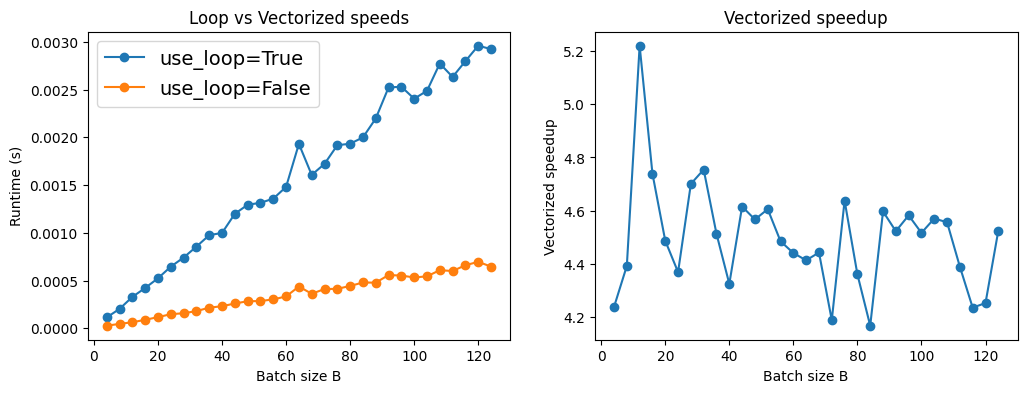

In [186]:
import time
import matplotlib.pyplot as plt
from pytorch101 import batched_matrix_multiply

N, M, P = 64, 64, 64 #矩阵尺寸固定: N=M=P=64
loop_times = []
no_loop_times = []
no_loop_speedup = []
Bs = list(range(4, 128, 4)) #批次大小B从4-127，每隔4取一个值
num_trials = 20
for B in Bs:
    loop_trials = []
    no_loop_trials = []
    for trial in range(num_trials):
        x = torch.randn(B, N, M)
        y = torch.randn(B, M, P)
        t0 = time.time()
        z1 = batched_matrix_multiply(x, y, use_loop=True)
        t1 = time.time()
        z2 = batched_matrix_multiply(x, y, use_loop=False)
        t2 = time.time()
        loop_trials.append(t1 - t0)
        no_loop_trials.append(t2 - t1)
    loop_mean = torch.tensor(loop_trials).mean().item()
    no_loop_mean = torch.tensor(no_loop_trials).mean().item()
    loop_times.append(loop_mean)
    no_loop_times.append(no_loop_mean)
    #在分母加上 1e-9(即0.000000001)
    no_loop_speedup.append(loop_mean / (no_loop_mean+1e-9)) #计算加速比

plt.subplot(1, 2, 1)
plt.plot(Bs, loop_times, 'o-', label='use_loop=True')
plt.plot(Bs, no_loop_times, 'o-', label='use_loop=False')
plt.xlabel('Batch size B')
plt.ylabel('Runtime (s)')
plt.legend(fontsize=14)
plt.title('Loop vs Vectorized speeds') #左图是两种方法的运行时间随批次大小的变化

plt.subplot(1, 2, 2)
plt.plot(Bs, no_loop_speedup, '-o')
plt.title('Vectorized speedup') #右图是向量化方法相对于循环的加速倍数
plt.xlabel('Batch size B')
plt.ylabel('Vectorized speedup')

plt.gcf().set_size_inches(12, 4) 
plt.show()

## Broadcasting

广播是一种强大的机制，它允许PyTorch在执行算术运算时处理不同形状的数组。通常，我们会有一个较小的张量和一个较大的张量，并且我们希望多次使用这个较小的张量对较大的张量执行某些运算。

例如，假设我们想将一个常数向量加到一个张量的每一行上。我们可以这样做：


In [187]:
# 我们将把向量v加到矩阵x的每一行中，
# 并将结果存储在矩阵y中
x = torch.tensor([[1,2,3], [4,5,6], [7,8,9], [10, 11, 12]])
v = torch.tensor([1, 0, 1])
y = torch.zeros_like(x)   # 创建一个与x形状相同的空矩阵

# 通过显式循环将向量v添加到矩阵x的每一行中
for i in range(4):
    y[i, :] = x[i, :] + v

print(y)

tensor([[ 2,  2,  4],
        [ 5,  5,  7],
        [ 8,  8, 10],
        [11, 11, 13]])


这是可行的；然而，当张量x非常大时，在Python中计算显式循环可能会很慢。请注意，将向量v添加到张量x的每一行，等同于通过垂直堆叠多个v的副本来形成一个张量vv，然后对x和vv进行逐元素求和。我们可以像这样实现这种方法：


In [188]:
vv = v.repeat((4, 1))  # 将v的4个副本堆叠在一起
print(vv)              # Prints "[[1 0 1]
                       #          [1 0 1]
                       #          [1 0 1]
                       #          [1 0 1]]"

tensor([[1, 0, 1],
        [1, 0, 1],
        [1, 0, 1],
        [1, 0, 1]])


In [189]:
y = x + vv  # 按元素相加x和vv
print(y)

tensor([[ 2,  2,  4],
        [ 5,  5,  7],
        [ 8,  8, 10],
        [11, 11, 13]])


PyTorch的广播机制使我们能够执行此计算，而无需实际创建v的多个副本。考虑以下使用广播机制的版本：

=

In [190]:
# 我们将把向量v加到矩阵x的每一行上，
# 并将结果存储在矩阵y中
x = torch.tensor([[1,2,3], [4,5,6], [7,8,9], [10, 11, 12]])
v = torch.tensor([1, 0, 1])
y = x + v  # 使用广播将v添加到x的每一行
print(y)

tensor([[ 2,  2,  4],
        [ 5,  5,  7],
        [ 8,  8, 10],
        [11, 11, 13]])


尽管x的形状为(4, 3)，v的形状为(3,)，但由于广播机制，y = x + v这条语句仍然有效；这条语句的运行方式就好像v实际上的形状是(4, 3)，其中每一行都是v的一个副本，然后进行逐元素相加。

将两个张量进行广播遵循以下规则：

1. 如果张量的秩（维度数）不同，则在秩较低的数组的形状前添加1，直到两个形状的长度相同。
2. 若两个张量在某个维度上的大小相同，或者其中一个张量在该维度上的大小为1，则称它们在该维度上是“兼容的”。
3. 只有当两个张量在所有维度上都兼容时，它们才能被一起广播。
4. 广播后，每个张量的行为就好像其形状等于两个输入张量形状的逐元素最大值。
5. 在任何维度上，如果一个张量的大小为1，而另一个张量的大小大于1，那么第一个张量的行为就好像它在该维度上被复制了一样。

如果这个解释不好理解，可以尝试阅读[文档](https://pytorch.org/docs/stable/notes/broadcasting.html)中的解释。

广播通常在许多PyTorch算子内部隐式发生。不过，我们也可以使用[`torch.broadcast_tensors`](https://pytorch.org/docs/stable/generated/torch.broadcast_tensors.html#torch.broadcast_tensors)函数来显式地进行广播：

In [191]:
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12]])
v = torch.tensor([1, 0, 1])
print('Here is x (before broadcasting):')
print(x)
print('x.shape: ', x.shape)
print('\nHere is v (before broadcasting):')
print(v)
print('v.shape: ', v.shape)

xx, vv = torch.broadcast_tensors(x, v)
print('Here is xx (after) broadcasting):')
print(xx)
print('xx.shape: ', x.shape)
print('\nHere is vv (after broadcasting):')
print(vv)
print('vv.shape: ', vv.shape)

Here is x (before broadcasting):
tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12]])
x.shape:  torch.Size([4, 3])

Here is v (before broadcasting):
tensor([1, 0, 1])
v.shape:  torch.Size([3])
Here is xx (after) broadcasting):
tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12]])
xx.shape:  torch.Size([4, 3])

Here is vv (after broadcasting):
tensor([[1, 0, 1],
        [1, 0, 1],
        [1, 0, 1],
        [1, 0, 1]])
vv.shape:  torch.Size([4, 3])


注意，广播后，`x`保持不变，但`v`的形状前多了一个维度，并且它会被复制以拥有与`x`相同的形状；由于广播后它们的形状相同，因此可以进行逐元素相加。

所有逐元素函数都支持广播。
一些非逐元素函数（如线性代数程序）也支持广播；
你可以查阅文档来确定某个特定函数是否支持广播。
例如，[`torch.mm`](https://pytorch.org/docs/stable/generated/torch.mm.html)不支持广播，
但[`torch.matmul`](https://pytorch.org/docs/stable/generated/torch.matmul.html)支持。

广播能让我们轻松实现许多不同的运算。例如，我们可以计算向量的外积：

In [192]:
# 计算向量的外积
v = torch.tensor([1, 2, 3])  # v has shape (3,)
w = torch.tensor([4, 5])     # w has shape (2,)
# 要计算外积，我们首先将v重塑为形状为(3, 1)的列向量；
# 然后我们可以将它与w进行广播，得到形状为(3, 2)的输出，这就是v和w的外积：
print(v.view(3,1))
print(v.view(3, 1) * w)

tensor([[1],
        [2],
        [3]])
tensor([[ 4,  5],
        [ 8, 10],
        [12, 15]])


我们可以给矩阵的每一行都加上一个向量：

In [193]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])  # x has shape (2, 3)
v = torch.tensor([1, 2, 3])               # v has shape (3,)
print('Here is the matrix:')
print(x)
print('\nHere is the vector:')
print(v)

# x的形状为(2, 3)，v的形状为(3,)，因此它们会广播为(2, 3)，
# 得到以下矩阵：
print('\nAdd the vector to each row of the matrix:')
print(x + v)

Here is the matrix:
tensor([[1, 2, 3],
        [4, 5, 6]])

Here is the vector:
tensor([1, 2, 3])

Add the vector to each row of the matrix:
tensor([[2, 4, 6],
        [5, 7, 9]])


我们可以将一个向量加到矩阵的每一列上：

In [194]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])  # x has shape (2, 3)
w = torch.tensor([4, 5])                  # w has shape (2,)
print('Here is the matrix:')
print(x)
print('\nHere is the vector:')
print(w)

# x的形状为(2, 3)，w的形状为(2,)。我们将w重塑为(2, 1)；
# 然后，当我们将两者相加时，结果会广播为(2, 3)：
print('\nAdd the vector to each column of the matrix:')
print(w.view(-1,1))
print(x + w.view(-1, 1))

# 另一种解决方案如下：
# 1. 对x进行转置，使其形状为(3, 2)
# 2. 由于w的形状为(2,)，相加时会广播为(3, 2)
# 3. 对结果进行转置，得到形状为(2, 3)的结果
print(x.t())
print((x.t() + w).t())

Here is the matrix:
tensor([[1, 2, 3],
        [4, 5, 6]])

Here is the vector:
tensor([4, 5])

Add the vector to each column of the matrix:
tensor([[4],
        [5]])
tensor([[ 5,  6,  7],
        [ 9, 10, 11]])
tensor([[1, 4],
        [2, 5],
        [3, 6]])
tensor([[ 5,  6,  7],
        [ 9, 10, 11]])


将一个张量乘以一组常数：

In [195]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])  # x has shape (2, 3)
c = torch.tensor([1, 10, 11, 100])        # c has shape (4)
print('Here is the matrix:')
print(x)
print('\nHere is the vector:')
print(c)

# 我们执行以下操作：
# 1. 将c从形状(4,)重塑为(4, 1, 1)
# 2. x的形状为(2, 3)。由于它们的秩不同，当我们将两者相乘时，x的行为就好像其形状是(1, 2, 3)
# 3. 形状为(4, 1, 1)的张量与形状为(1, 2, 3)的张量之间的广播乘法结果的形状为(4, 2, 3)
# 4. 结果y的形状为(4, 2, 3)，且y[i]（形状为(2, 3)）等于c[i] * x
y = c.view(-1, 1, 1) * x
print('\nMultiply x by a set of constants:')
print(y)

Here is the matrix:
tensor([[1, 2, 3],
        [4, 5, 6]])

Here is the vector:
tensor([  1,  10,  11, 100])

Multiply x by a set of constants:
tensor([[[  1,   2,   3],
         [  4,   5,   6]],

        [[ 10,  20,  30],
         [ 40,  50,  60]],

        [[ 11,  22,  33],
         [ 44,  55,  66]],

        [[100, 200, 300],
         [400, 500, 600]]])


**轮到你了**：在文件`pytorch101.py`中，实现函数`normalize_columns`，该函数用于对矩阵的列进行标准化处理。它需要计算每列的均值和标准差，然后对于列中的每个元素，减去该列的均值并除以该列的标准差。

示例：
```
x = [[ 0,  30,  600],
     [ 1,  10,  200],
     [-1,  20,  400]]
```
- 第一列的均值为0，标准差为1
- 第二列的均值为20，标准差为10
- 第三列的均值为400，标准差为200

对列进行标准化后，结果应为：
```
y = [[ 0,  1,  1],
     [ 1, -1, -1],
     [-1,  0,  0]]
```

回想一下，对于标量$x_1,\ldots,x_M$，均值$\mu$和标准差$\sigma$的计算公式如下：

$$\mu=\frac{1}{M}\sum_{i=1}^M x_i \hspace{4pc} \sigma = \sqrt{\frac{1}{M-1}\sum_{i=1}^M(x_i-\mu)^2}$$

In [196]:
from pytorch101 import normalize_columns

x = torch.tensor([[0., 30., 600.], [1., 10., 200.], [-1., 20., 400.]])
y = normalize_columns(x)
print('Here is x:')
print(x)
print('Here is y:')
print(y)

x_expected = [[0., 30., 600.], [1., 10., 200.], [-1., 20., 400.]]
y_expected = [[0., 1., 1.], [1., -1., -1.], [-1., 0., 0.]]
y_correct = y.tolist() == y_expected
x_correct = x.tolist() == x_expected
print('y correct: ', y_correct)
print('x unchanged: ', x_correct)

Here is x:
tensor([[  0.,  30., 600.],
        [  1.,  10., 200.],
        [ -1.,  20., 400.]])
Here is y:
tensor([[ 0.,  1.,  1.],
        [ 1., -1., -1.],
        [-1.,  0.,  0.]])
y correct:  True
x unchanged:  True


### Out-of-place vs in-place operators
大多数PyTorch运算符可分为以下两类：
- **原地外运算符**：返回一个新的张量。大多数PyTorch运算符都以这种方式工作。
- **原地运算符**：修改并返回输入张量。以下划线结尾的实例方法（如`add_()`）是原地运算符。`torch`命名空间中的运算符可以通过`out=`关键字参数变为原地运算符。

例如：

In [197]:
# 原地外加法会创建并返回一个新的张量，而不会修改输入的张量：
x = torch.tensor([1, 2, 3])
y = torch.tensor([3, 4, 5])
print('Out-of-place addition:')
print('Before addition:')
print('x: ', x)
print('y: ', y)
z = x.add(y)  # 与 z = x + y 或 z = torch.add(x, y) 相同
print('\nAfter addition (x and y unchanged):')
print('x: ', x)
print('y: ', y)
print('z: ', z)
print('z is x: ', z is x)
print('z is y: ', z is y)

# 原地加法会修改输入张量：
print('\n\nIn-place Addition:')
print('Before addition:')
print('x: ', x)
print('y: ', y)
x.add_(y)  # 与x += y或torch.add(x, y, out=x)相同
print('\nAfter addition (x is modified):')
print('x: ', x)
print('y: ', y)
print('z: ', z)
print('z is x: ', z is x)
print('z is y: ', z is y)

Out-of-place addition:
Before addition:
x:  tensor([1, 2, 3])
y:  tensor([3, 4, 5])

After addition (x and y unchanged):
x:  tensor([1, 2, 3])
y:  tensor([3, 4, 5])
z:  tensor([4, 6, 8])
z is x:  False
z is y:  False


In-place Addition:
Before addition:
x:  tensor([1, 2, 3])
y:  tensor([3, 4, 5])

After addition (x is modified):
x:  tensor([4, 6, 8])
y:  tensor([3, 4, 5])
z:  tensor([4, 6, 8])
z is x:  False
z is y:  False


一般来说，**你应该避免原地操作**，因为在使用自动求导（我们将在后续作业中介绍）计算梯度时，原地操作可能会引发问题。

## Running on GPU

**注意：本节需要GPU！如果您的电脑没有支持CUDA的GPU，可以在Google Colab上完成本笔记本的这部分内容。**

PyTorch最重要的特性之一是它可以使用图形处理器（GPU）来加速其张量运算。

我们可以轻松检查PyTorch是否配置为使用GPU：

张量可以使用.to方法移至任何设备上。

In [198]:
import torch

if torch.cuda.is_available():
  print('PyTorch can use GPUs!')
else:
  print('PyTorch cannot use GPUs.')

PyTorch can use GPUs!


你可以通过“运行时”->“更改运行时类型”->“硬件加速器”->“GPU”来在Colab中启用GPU。

这可能会导致Colab运行时重启，因此我们将在下一个单元格中重新导入torch。

我们已经了解到，PyTorch张量有一个`dtype`属性，用于指定它们的数据类型。所有PyTorch张量还有一个`device`属性，用于指定存储张量的设备——要么是CPU，要么是CUDA（适用于NVIDIA GPU）。CUDA设备上的张量会自动使用该设备来加速其所有运算。

与数据类型一样，我们可以使用[`.to()`](https://pytorch.org/docs/1.1.0/tensors.html#torch.Tensor.to)方法来更改张量的设备。我们也可以使用便捷方法`.cuda()`和`.cpu()`在CPU和GPU之间移动张量。

In [199]:
# 在CPU上构造一个张量
x0 = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
print('x0 device:', x0.device)

# 使用.to()将其移至GPU
x1 = x0.to('cuda')
print('x1 device:', x1.device)

# 使用.cuda()将其移至GPU
x2 = x0.cuda()
print('x2 device:', x2.device)

# 使用.to()将其移回CPU
x3 = x1.to('cpu')
print('x3 device:', x3.device)

# 使用.cpu()将其移回CPU
x4 = x2.cpu()
print('x4 device:', x4.device)

# 我们也可以直接在GPU上构建张量。
y = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float64, device='cuda')
print('y device / dtype:', y.device, y.dtype)

# 当 y 是张量时，调用 x.to(y) 会返回 x 的一个副本，该副本具有与 y 相同的设备和数据类型
x5 = x0.to(y)
print('x5 device / dtype:', x5.device, x5.dtype)

x0 device: cpu
x1 device: cuda:0
x2 device: cuda:0
x3 device: cpu
x4 device: cpu
y device / dtype: cuda:0 torch.float64
x5 device / dtype: cuda:0 torch.float64


在GPU上执行大型张量运算可能比在CPU上运行同等运算**快得多**。

在这里，我们比较在CPU和GPU上对两个形状为（10000，10000）的张量进行加法运算的速度：

（请注意，GPU代码可能与CPU代码异步运行，因此在对GPU上的运算速度进行计时时，使用`torch.cuda.synchronize`来同步CPU和GPU非常重要。）

In [205]:
import torch

print(hasattr(torch, "device"))
print(torch.cuda.is_available())
print(dir(torch)[:50])


True
True
['AVG', 'AcceleratorError', 'AggregationType', 'AliasDb', 'AnyType', 'Argument', 'ArgumentSpec', 'AwaitType', 'BFloat16Storage', 'BFloat16Tensor', 'BenchmarkConfig', 'BenchmarkExecutionStats', 'Block', 'BoolStorage', 'BoolTensor', 'BoolType', 'BufferDict', 'ByteStorage', 'ByteTensor', 'CallStack', 'Capsule', 'CharStorage', 'CharTensor', 'ClassType', 'Code', 'CompilationUnit', 'CompleteArgumentSpec', 'ComplexDoubleStorage', 'ComplexFloatStorage', 'ComplexType', 'ConcreteModuleType', 'ConcreteModuleTypeBuilder', 'DeepCopyMemoTable', 'DeserializationStorageContext', 'DeviceObjType', 'DictType', 'DisableTorchFunction', 'DisableTorchFunctionSubclass', 'DispatchKey', 'DispatchKeySet', 'DoubleStorage', 'DoubleTensor', 'EnumType', 'ErrorReport', 'Event', 'ExcludeDispatchKeyGuard', 'ExecutionPlan', 'FatalError', 'FileCheck', 'FloatStorage']


In [203]:
import time

a_cpu = torch.randn(10000, 10000, dtype=torch.float32)
b_cpu = torch.randn(10000, 10000, dtype=torch.float32)

a_gpu = a_cpu.cuda()
b_gpu = b_cpu.cuda()
torch.cuda.synchronize()

t0 = time.time()
c_cpu = a_cpu + b_cpu
t1 = time.time()
c_gpu = a_gpu + b_gpu
torch.cuda.synchronize()
t2 = time.time()

# Check that they computed the same thing
diff = (c_gpu.cpu() - c_cpu).abs().max().item()
print('Max difference between c_gpu and c_cpu:', diff)

cpu_time = 1000.0 * (t1 - t0)
gpu_time = 1000.0 * (t2 - t1)
print('CPU time: %.2f ms' % cpu_time)
print('GPU time: %.2f ms' % gpu_time)
print('GPU speedup: %.2f x' % (cpu_time / gpu_time))

AttributeError: module 'torch' has no attribute 'device'

你会发现，在GPU上运行相同的计算比在CPU上快10到30倍以上！由于GPU能带来巨大的速度提升，从作业2开始，我们将使用GPU来加速我们的大部分机器学习代码。

**该你试试了**：使用GPU来加速下面的矩阵乘法运算。通过使用GPU，你应该能看到5到10倍的速度提升。

In [207]:
import time
from pytorch101 import mm_on_cpu, mm_on_gpu

x = torch.rand(512, 4096)
w = torch.rand(4096, 4096)

t0 = time.time()
y0 = mm_on_cpu(x, w)
t1 = time.time()

y1 = mm_on_gpu(x, w)
torch.cuda.synchronize()
t2 = time.time()

print('y1 on CPU:', y1.device == torch.device('cpu'))
diff = (y0 - y1).abs().max().item()
print('Max difference between y0 and y1:', diff)
print('Difference within tolerance:', diff < 5e-2)

cpu_time = 1000.0 * (t1 - t0)
gpu_time = 1000.0 * (t2 - t1)
print('CPU time: %.2f ms' % cpu_time)
print('GPU time: %.2f ms' % gpu_time)
print('GPU speedup: %.2f x' % (cpu_time / gpu_time))

AttributeError: module 'torch' has no attribute 'device'

完成了！现在你可以转到kNN.ipynb。在你转移之前，请检查你是否在每个ipynb文件中生成了任何额外的单元格（例如，最后一个代码单元格后面的空单元格）。